In [17]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from windrose import WindroseAxes

pd.set_option('display.max_columns', None)

In [39]:
wind = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Tow_setup_check\\Mesonet_wind_dir.csv')
control = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_controltow_flux.csv')
KSP = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2024_KSP_flux.csv')
array = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_arraytow_flux.csv')

In [40]:
wind.rename(columns={'valid': 'date'}, inplace = True) #mesonet wind direction data
dtts_MN = pd.to_datetime(wind.date, format = '%Y-%m-%d %H:%M') #datetime timestamp for mesonet data
wind.set_index(dtts_MN, inplace = True)

dtts_KSC = pd.to_datetime(control.TIMESTAMP, format = '%Y-%m-%d %H:%M:%S') #datetime timestamp for control tower data
control.set_index(dtts_KSC, inplace = True)
dtts_KSA = pd.to_datetime(array.TIMESTAMP, format = '%Y-%m-%d %H:%M:%S') #datetime timestamp for array tower data
array.set_index(dtts_KSA, inplace = True)
dtts_KSP = pd.to_datetime(KSP.TIMESTAMP, format = '%Y-%m-%d %H:%M:%S') #datetime timestamp for array tower data
KSP.set_index(dtts_KSP, inplace = True)

JVL = wind[wind['station']=='JVL']['drct']
MSN = wind[wind['station']=='MSN']['drct']
RYV = wind[wind['station']=='RYV']['drct']
EFT = wind[wind['station']=='EFT']['drct']
KSC = control['wnd_dir_compass']
KSC_spd = control['wnd_spd']
KSA = array['wnd_dir_compass']
KSA_spd = array['wnd_spd']

KSP_dir = KSP['wnd_dir_compass']
KSP_spd= KSP['wnd_spd']

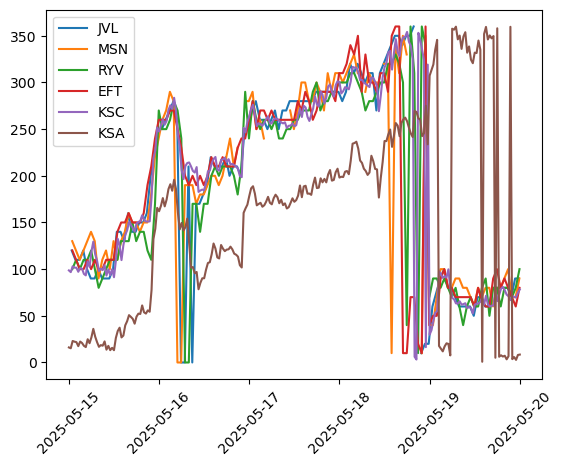

In [9]:
startdate = dt.datetime(2025, 5, 15)
enddate = dt.datetime(2025, 5, 20)

sites = {'JVL':JVL,'MSN': MSN, 'RYV':RYV, 'EFT':EFT, 'KSC':KSC, 'KSA':KSA}

for station in sites.keys():
    plt.plot(sites[station][startdate:enddate], label = station)
plt.xticks(rotation = 45);
plt.legend()

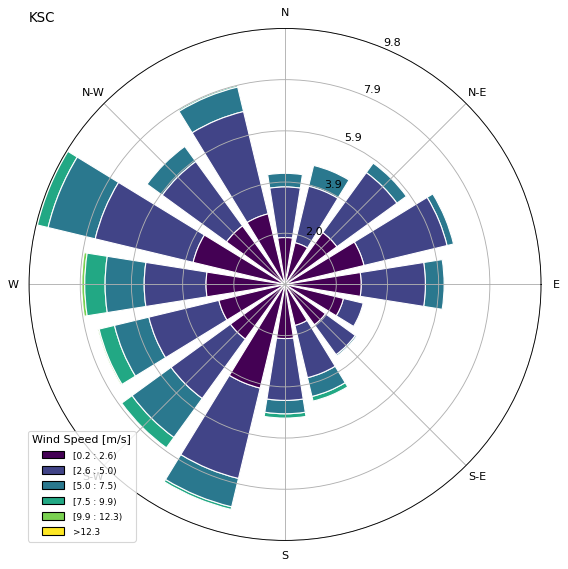

In [42]:
ax = WindroseAxes.from_ax()
ax.bar(KSC, KSC_spd, normed=True, opening=0.8, edgecolor="white")
ax.set_title('KSC',loc='left')
ax.set_legend(title = 'Wind Speed [m/s]')

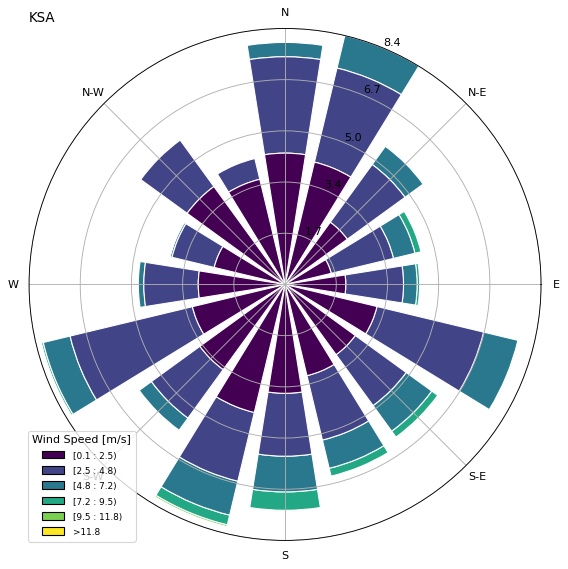

In [36]:
ax = WindroseAxes.from_ax()
ax.bar(KSA, KSA_spd, normed=True, opening=0.8, edgecolor="white")
ax.set_title('KSA',loc='left')
ax.set_legend(title = 'Wind Speed [m/s]')

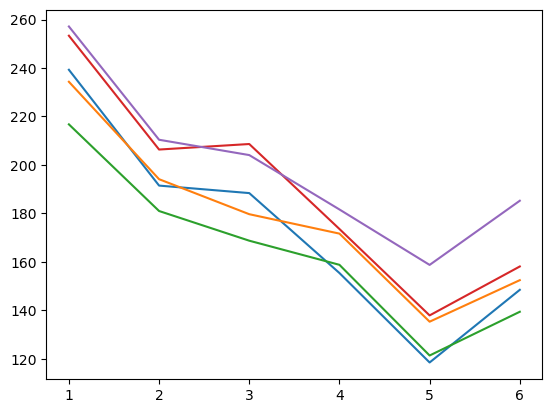

In [88]:
other_sites = pd.DataFrame()
for station in list(sites.keys())[0:5]:
    other_sites[station] = sites[station].groupby(sites[station].index.month).mean()
other_sites

plt.plot(other_sites);

88.69960245287025


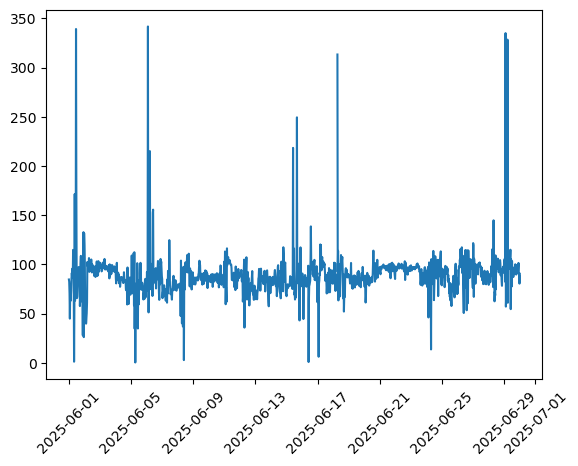

In [59]:
var = 'wnd_dir_compass'
diff = ((control[var]-array[var])+360)%360
startdate = dt.datetime(2025, 6, 1)
enddate = dt.datetime(2025, 6, 30)
plt.plot(diff[startdate:enddate])
# plt.plot(KSC[startdate:enddate])
plt.xticks(rotation = 45);
print(diff.mean())

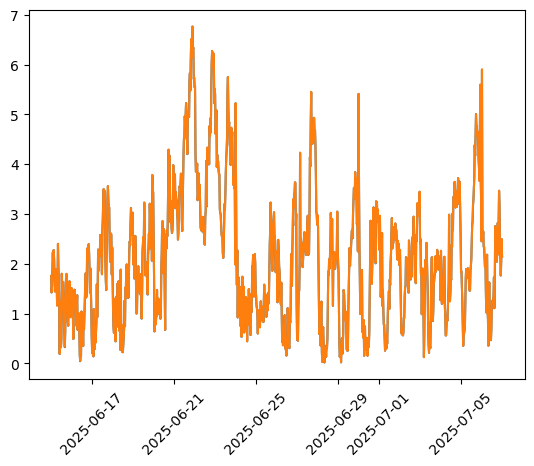

In [ ]:
#Comparing wind speed from Ux, Uy to total wind speed
#Exactly lines up with 'rslt_wnd_spd'
startdate = dt.datetime(2025, 6, 15)
enddate = dt.datetime(2025, 7, 7)
KSA_spd = (array['Ux_Avg']**2 + array['Uy_Avg']**2)**(1/2)
plt.plot(array['wnd_spd'][startdate:enddate])
plt.plot(KSA_spd2[startdate:enddate])

# KSC_spd = (control['Ux_Avg']**2 + control['Uy_Avg']**2)**(1/2)
# plt.plot(control['wnd_spd'][startdate:enddate])
# plt.plot(KSC_spd[startdate:enddate])
plt.xticks(rotation = 45);

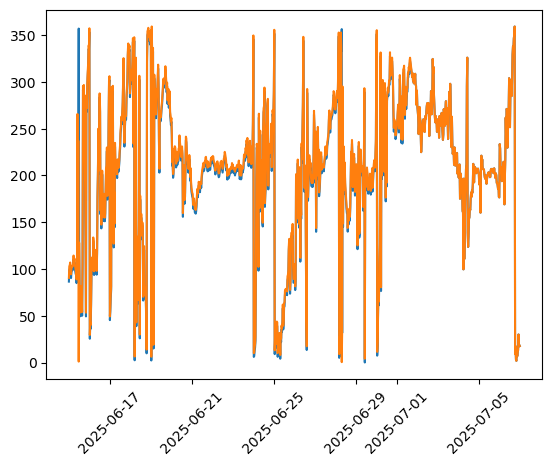

In [ ]:
#Calculate Wind direction from Ux and Uy
tow = control
az = 185
# az = 217 # array tower azimuth 
Ux = tow['Ux_Avg']
Uy = tow['Uy_Avg']

U_dir = ((np.arctan2(Ux, Uy)*180/np.pi) + az + 270) % 360 

plt.plot(U_dir[startdate:enddate])
plt.plot(tow['wnd_dir_compass'][startdate:enddate])
plt.xticks(rotation = 45);

In [12]:
array.columns

Index(['Unnamed: 0', 'TIMESTAMP', 'RECORD', 'Hs', 'tau', 'u_star', 'Ts_stdev',
       'Ts_Ux_cov', 'Ts_Uy_cov', 'Ts_Uz_cov', 'Ux_stdev', 'Ux_Uy_cov',
       'Ux_Uz_cov', 'Uy_stdev', 'Uy_Uz_cov', 'Uz_stdev', 'wnd_spd',
       'rslt_wnd_spd', 'wnd_dir_sonic', 'std_wnd_dir', 'wnd_dir_compass',
       'Ux_Avg', 'Uy_Avg', 'Uz_Avg', 'Ts_Avg', 'sonic_azimuth',
       'sonic_samples_Tot', 'diag_sonic_aggregate', 'no_sonic_head_Tot',
       'no_new_sonic_data_Tot', 'sonic_amp_l_f_Tot', 'sonic_amp_h_f_Tot',
       'sonic_sig_lck_f_Tot', 'sonic_del_T_f_Tot', 'sonic_aq_sig_f_Tot',
       'sonic_cal_err_f_Tot', 'Fc_wpl', 'LE_wpl', 'Hc', 'CO2_stdev',
       'CO2_Ux_cov', 'CO2_Uy_cov', 'CO2_Uz_cov', 'H2O_stdev', 'H2O_Ux_cov',
       'H2O_Uy_cov', 'H2O_Uz_cov', 'Tc_stdev', 'Tc_Ux_cov', 'Tc_Uy_cov',
       'Tc_Uz_cov', 'CO2_mean', 'H2O_mean', 'amb_tmpr_Avg', 'amb_press_mean',
       'Tc_mean', 'rho_a_mean', 'Fc_irga', 'LE_irga', 'CO2_wpl_LE',
       'CO2_wpl_H', 'H2O_wpl_LE', 'H2O_wpl_H', 'irga_samples